# Forecasting precipitation with NeuralGCM (2.8° stochastic)

The **2.8° stochastic precipitation model** is trained to match satellite-based precipitation observations; it produces realistic cumulative precipitation at 6-hourly and longer accumulations.

These models add two outputs to the forecast:
`precipitation_cumulative_mean` (accumulated precipitation in meters
since the forecast start, computed by a learned water-budget closure) and
`evaporation` (a rate in kg m⁻² s⁻¹, ERA5 sign convention: negative over
evaporating surfaces). See the
[paper](https://arxiv.org/abs/2412.11973) and
[checkpoints.md](https://github.com/neuralgcm/neuralgcm/blob/main/docs/checkpoints.md)
for the trade-offs between the two variants. Needs network access
(checkpoint + ERA5, anonymous GCS) and a GPU.

In [2]:
import pathlib

import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load the model

In [3]:
from neuralgcm_torch import pretrained

# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint('stochastic_precip_2_8_deg', local_root='checkpoints')
model = neuralgcm.PressureLevelModel.from_checkpoint(converted_path, device=device)
(model.longitudes.size, model.latitudes.size,
 sum(p.numel() for p in model.model.parameters()))

(128, 64, 11145090)

## Load and regrid ERA5

In [4]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # process every 24th hour

sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

era5_grid = xarray_utils.grid_spec_from_dataset(full_era5)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_grid, skipna=True, device=device
)
eval_era5 = xarray_utils.regrid_horizontal(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

## Make the forecast (stochastic: the seed matters)

In [5]:
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 4 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps  # time axis in hours

inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
initial_state = model.encode(inputs, input_forcings, rng=42)

# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)

## Forecast skill

In [6]:
target_trajectory = model.inputs_from_xarray(
    eval_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

w = np.cos(np.deg2rad(combined_ds.latitude))
t850 = combined_ds.sel(level=850).temperature.isel(time=-1)
rmse = float(np.sqrt(
    ((t850.sel(model='NeuralGCM') - t850.sel(model='ERA5')) ** 2)
    .weighted(w).mean()
))
persistence = float(np.sqrt(
    ((combined_ds.sel(model='ERA5', level=850).temperature.isel(time=0)
      - t850.sel(model='ERA5')) ** 2).weighted(w).mean()
))
print(f'day-4 T850 RMSE: forecast {rmse:.2f} K, persistence {persistence:.2f} K')

day-4 T850 RMSE: forecast 1.44 K, persistence 4.15 K


## Daily precipitation

The cumulative precipitation output differenced over the daily output
interval gives daily accumulations (×1000 for mm/day):

global mean precipitation (mm/day): [2.94 3.31 3.27]


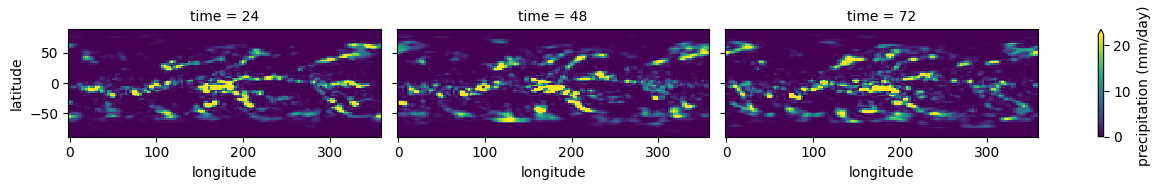

In [7]:
daily_precip_mm = (
    predictions_ds.precipitation_cumulative_mean.diff('time') * 1000
).squeeze('surface', drop=True)
w = np.cos(np.deg2rad(predictions_ds.latitude))
global_mean = daily_precip_mm.weighted(w).mean(['longitude', 'latitude'])
print('global mean precipitation (mm/day):', np.round(global_mean.data, 2))
daily_precip_mm.plot(
    x='longitude', y='latitude', col='time', robust=True, aspect=2, size=2,
    cbar_kwargs={'label': 'precipitation (mm/day)'},
);

## Evaporation rate (day 4)

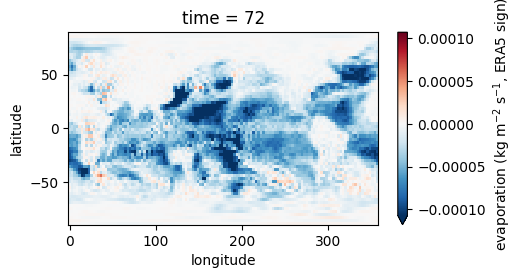

In [8]:
predictions_ds.evaporation.isel(time=-1).squeeze('surface', drop=True).plot(
    x='longitude', y='latitude', robust=True, aspect=2, size=2.5,
    cbar_kwargs={'label': 'evaporation (kg m$^{-2}$ s$^{-1}$, ERA5 sign)'},
);